In [1]:
%matplotlib inline

In [2]:
import os
import cv2
import glob
from ultralytics import YOLO
import matplotlib.pyplot as plt

##Dataset Loading

In [3]:
#Define the dataset path
dataset_path = f"./dataset"

pathFolder = os.listdir(dataset_path)
imagesFolder = os.listdir(dataset_path +"/images")
labelsFolder = os.listdir(dataset_path +"/labels")

print(f"Path: {pathFolder} \nImages: {imagesFolder} \nLabels: {labelsFolder}")

Path: ['images', 'labels'] 
Images: ['test', 'train', 'val'] 
Labels: ['test', 'train', 'train.cache', 'val', 'val.cache']


##Dataset Configuration File

In [4]:
#Create the YOLO dataset configuration file
data_yaml = f"""
path: {dataset_path}

train: images/train
val: images/val
test: images/test

names:
  0: weed_1
  1: weed_2
  2: weed_3
  3: weed_4
  4: weed_5
  5: weed_6
  6: weed_7
"""

# Save the configuration file
with open("data.yaml", "w") as f:
  f.write(data_yaml)

# Print the contents of the configuration file
with open("data.yaml", "r") as f:
    print(f.read())


path: ./dataset

train: images/train
val: images/val
test: images/test

names:
  0: weed_1
  1: weed_2
  2: weed_3
  3: weed_4
  4: weed_5
  5: weed_6
  6: weed_7



##Load YOLOv8 Model
######Train
######Evaluate
######Test

Training parameters:
*   epochs: number of training iterations over the dataset
*   imgsz: image resolution used during training
*   batch: number of images processed per training batch

######YOLOv8n

In [5]:
#Train
# Load the pretrained YOLOv8 model
#The nano version is used because it provides fast training and requires less computational power
model_n = YOLO("yolov8n.pt")

results_n = model_n.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=6,
    cache=True,
    close_mosaic=10,
    augment=True,
    optimizer="SGD",
    project="weed_detection",
    name="yolov8n_model",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.19  Python-3.13.2 torch-2.10.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_model, nbs=64, nm

In [6]:
#Evaluate
#Evaluate the trained model on the validation dataset
metrics_n = model_n.val()
print(metrics_n)

Ultralytics 8.4.19  Python-3.13.2 torch-2.10.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3430.4307.4 MB/s, size: 10190.4 KB)
val: Scanning C:\Users\ushin\Desktop\Project\dataset\labels\val.cache... 169 images, 2 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 169/169 54.5Mit/s 0.0s
val: C:\Users\ushin\Desktop\Project\dataset\images\val\DJI_20250411121923_0571_D.JPG: ignoring corrupt image/label: Label class 6 exceeds dataset class count 6. Possible class labels are 0-5
val: C:\Users\ushin\Desktop\Project\dataset\images\val\DJI_20250411122324_0631_D.JPG: ignoring corrupt image/label: Label class 6 exceeds dataset class count 6. Possible class labels are 0-5
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.4s/it 26.9s2.6s
                   all        167       6685      0.111      0.112     0.0

In [7]:
#Test
# Run detection on the test dataset. Predictions will be saved automatically
test_results_n = model_n.predict(
    source=dataset_path + "/images/test",
    save=False,
    conf=0.05
    # name="yolov8n_predictions"
)


image 1/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113746_0003_D.JPG: 480x640 6 weed_1s, 3 weed_3s, 49.0ms
image 2/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113807_0011_D.JPG: 480x640 1 weed_1, 5 weed_3s, 41.1ms
image 3/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113858_0024_D.JPG: 480x640 2 weed_1s, 37.5ms
image 4/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113922_0030_D.JPG: 480x640 5 weed_2s, 1 weed_3, 45.8ms
image 5/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113928_0032_D.JPG: 480x640 10 weed_2s, 37.7ms
image 6/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411114002_0040_D.JPG: 480x640 1 weed_3, 40.3ms
image 7/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411114032_0048_D.JPG: 480x640 (no detections), 38.2ms
image 8/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411114040_0050_D.JPG: 480x640 42 weed_1s, 6 weed_2

######Visualizing Predictions

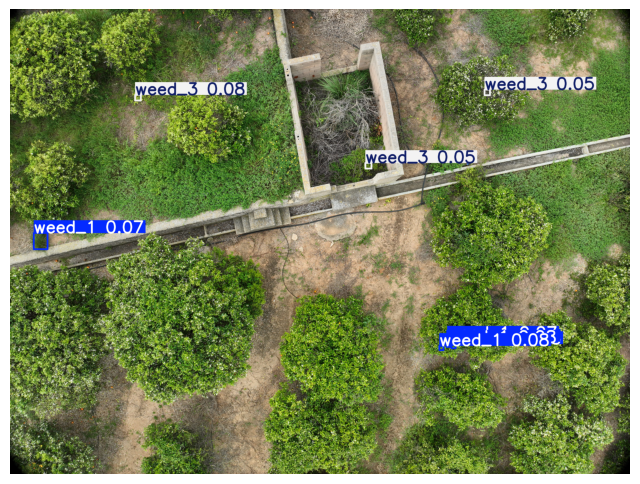

In [8]:
#Display predicted images
plt.ion()

for r in test_results_n:
    if len(r.boxes) > 6:
        img = r.plot()
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8,8))
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        plt.pause(0.001)
        break #Show only one image for demonstration purposes

In [9]:
#Save the trained model.
model_n.export(format="onnx")

Ultralytics 8.4.19  Python-3.13.2 torch-2.10.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)

PyTorch: starting from 'C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8n_model\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 11, 8400) (6.0 MB)

ONNX: starting export with onnx 1.20.1 opset 22...


c:\Users\ushin\Desktop\Project\.venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success  1.5s, saved as 'C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8n_model\weights\best.onnx' (11.7 MB)

Export complete (1.6s)
Results saved to C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8n_model\weights
Predict:         yolo predict task=detect model=C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8n_model\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8n_model\weights\best.onnx imgsz=640 data=data.yaml  
Visualize:       https://netron.app


'C:\\Users\\ushin\\Desktop\\Project\\runs\\detect\\weed_detection\\yolov8n_model\\weights\\best.onnx'

######YOLOv8s

In [10]:
# Train
# Load YOLOv8s model
model_s = YOLO("yolov8s.pt")

results_s = model_s.train(
  data="data.yaml",
  epochs=50,
  imgsz=640,
  batch=16,
  workers=6,
  cache=True,
  close_mosaic=10,
  augment=True,
  optimizer="AdamW",
  project="weed_detection",
  name="yolov8s_model",
  exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.19  Python-3.13.2 torch-2.10.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_model, nbs=64, nm

In [11]:
#Evaluate
metrics_s = model_s.val()
print(metrics_s)

Ultralytics 8.4.19  Python-3.13.2 torch-2.10.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
Model summary (fused): 73 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1508.6581.5 MB/s, size: 10190.4 KB)
val: Scanning C:\Users\ushin\Desktop\Project\dataset\labels\val.cache... 169 images, 2 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 169/169 54.5Mit/s 0.0s
val: C:\Users\ushin\Desktop\Project\dataset\images\val\DJI_20250411121923_0571_D.JPG: ignoring corrupt image/label: Label class 6 exceeds dataset class count 6. Possible class labels are 0-5
val: C:\Users\ushin\Desktop\Project\dataset\images\val\DJI_20250411122324_0631_D.JPG: ignoring corrupt image/label: Label class 6 exceeds dataset class count 6. Possible class labels are 0-5
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.7s/it 41.1s4.0s
                   all        167       6685     0.0665     0.0854     0

In [12]:
#Test
test_results_s = model_s.predict(
    source=dataset_path + "/images/test",
    save=False,
    conf=0.05
    # name="yolov8s_predictions"
)


image 1/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113746_0003_D.JPG: 480x640 1 weed_1, 3 weed_2s, 116.1ms
image 2/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113807_0011_D.JPG: 480x640 22 weed_1s, 17 weed_2s, 86.4ms
image 3/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113858_0024_D.JPG: 480x640 1 weed_2, 1 weed_3, 86.1ms
image 4/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113922_0030_D.JPG: 480x640 4 weed_1s, 4 weed_2s, 108.5ms
image 5/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411113928_0032_D.JPG: 480x640 6 weed_1s, 1 weed_2, 2 weed_3s, 88.3ms
image 6/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411114002_0040_D.JPG: 480x640 2 weed_3s, 87.4ms
image 7/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411114032_0048_D.JPG: 480x640 (no detections), 87.9ms
image 8/170 c:\Users\ushin\Desktop\Project\dataset\images\test\DJI_20250411114040_0050_

######Visualizing Predictions

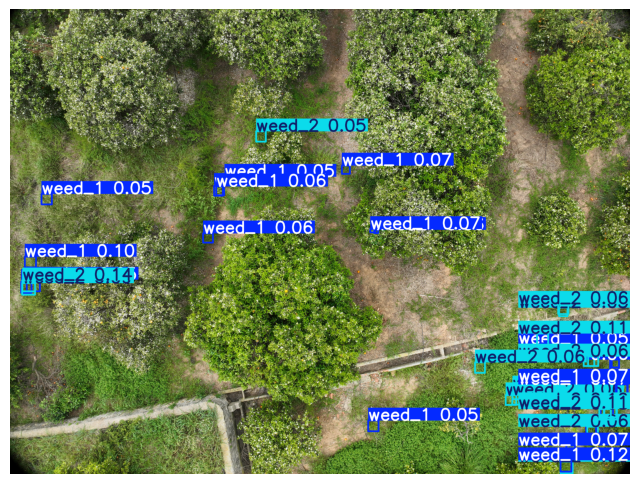

In [13]:
#Display predicted images
plt.ion()

for r in test_results_s:
    if len(r.boxes) > 6:
        img = r.plot()
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8,8))
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        plt.pause(0.001)
        break #Show only one image for demonstration purposes

In [14]:
# Save the trained model
model_s.export(format="onnx")

Ultralytics 8.4.19  Python-3.13.2 torch-2.10.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)

PyTorch: starting from 'C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8s_model\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 11, 8400) (21.5 MB)

ONNX: starting export with onnx 1.20.1 opset 22...


c:\Users\ushin\Desktop\Project\.venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success  1.4s, saved as 'C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8s_model\weights\best.onnx' (42.7 MB)

Export complete (1.7s)
Results saved to C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8s_model\weights
Predict:         yolo predict task=detect model=C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8s_model\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=C:\Users\ushin\Desktop\Project\runs\detect\weed_detection\yolov8s_model\weights\best.onnx imgsz=640 data=data.yaml  
Visualize:       https://netron.app


'C:\\Users\\ushin\\Desktop\\Project\\runs\\detect\\weed_detection\\yolov8s_model\\weights\\best.onnx'